# Perbandingan Distance Metric pada DBSCAN

Notebook ini membandingkan tiga distance metric pada DBSCAN:

- `euclidean`
- `manhattan`
- `cosine`

Semua pengujian menggunakan **dataset, preprocessing, EPS, MIN_SAMPLES, algorithm, dan n_jobs yang sama** agar perubahan hasil berasal dari distance metric.

Parameter yang digunakan mengikuti ketiga notebook sumber:

- `EPS = 0.5`
- `MIN_SAMPLES = 5`
- `algorithm = "brute"`
- `n_jobs = 1`

Tabel perbandingan berisi:

1. Jumlah kluster
2. Waktu eksekusi DBSCAN
3. Silhouette Score
4. Penggunaan memori puncak

> Waktu dan memori yang diukur adalah proses `DBSCAN.fit_predict()`. Silhouette dihitung setelah clustering pada seluruh data non-noise dengan distance metric yang sama.


## 1. Import Library


In [36]:
import gc
import time
import tracemalloc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


## 2. Membaca Dataset


In [37]:
FILE = "dataset_B_05_2020 (1).csv"

df = pd.read_csv(FILE)

print("Shape dataset:", df.shape)
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])


Shape dataset: (11430, 89)
Jumlah data: 11430
Jumlah kolom: 89


## 3. Mengambil Fitur Numerik

Kolom `url` dan `status` tidak digunakan untuk clustering. `status` tetap disimpan sebagai label asli apabila dibutuhkan untuk analisis terpisah.


In [38]:
urls = df["url"].copy()
labels = df["status"].copy()

# Hanya fitur numerik
X = df.drop(columns=["url", "status"])
X = X.select_dtypes(include=np.number)

print("Shape fitur numerik:", X.shape)
display(df.head())


Shape fitur numerik: (11430, 87)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


## 4. Menangani Missing Value


In [39]:
print("Total missing value sebelum imputasi:", X.isna().sum().sum())

X = X.fillna(X.median())

print("Total missing value setelah imputasi:", X.isna().sum().sum())


Total missing value sebelum imputasi: 0
Total missing value setelah imputasi: 0


## 5. Menghapus Fitur Konstan


In [40]:
selector = VarianceThreshold(threshold=0)

X_selected = selector.fit_transform(X)

selected_features = X.columns[selector.get_support()]

X_selected = pd.DataFrame(
    X_selected,
    columns=selected_features
)

print("Setelah menghapus fitur konstan:")
print("Shape:", X_selected.shape)
print("Jumlah fitur:", len(selected_features))


Setelah menghapus fitur konstan:
Shape: (11430, 81)
Jumlah fitur: 81


## 6. StandardScaler


In [41]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_selected)

print("Setelah StandardScaler:")
print("Shape:", X_scaled.shape)


Setelah StandardScaler:
Shape: (11430, 81)


## 7. Parameter Pengujian

`EPS` dan `MIN_SAMPLES` sengaja dibuat sama untuk seluruh distance metric agar perbandingannya konsisten.


In [42]:
DISTANCE_METRICS = [
    "euclidean",
    "manhattan",
    "cosine",
]

EPS = 0.5
MIN_SAMPLES = 5

print("Distance metrics :", DISTANCE_METRICS)
print("EPS              :", EPS)
print("MIN_SAMPLES      :", MIN_SAMPLES)


Distance metrics : ['euclidean', 'manhattan', 'cosine']
EPS              : 0.5
MIN_SAMPLES      : 5


## 8. Fungsi Benchmark DBSCAN

Penggunaan memori diukur dengan `tracemalloc` dan dilaporkan sebagai **peak tracked memory** selama `fit_predict()`.

Silhouette Score dihitung hanya jika data non-noise memiliki minimal dua kluster.


In [43]:
def benchmark_dbscan(X_data, metric, eps, min_samples):
    gc.collect()

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric=metric,
        algorithm="brute",
        n_jobs=1
    )

    tracemalloc.start()
    start_time = time.perf_counter()

    cluster_labels = model.fit_predict(X_data)

    execution_time = time.perf_counter() - start_time
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    peak_memory_mb = peak_memory / (1024 ** 2)

    noise_mask = cluster_labels == -1
    n_clusters = len(set(cluster_labels)) - int(noise_mask.any())

    X_evaluation = X_data[~noise_mask]
    labels_evaluation = cluster_labels[~noise_mask]
    n_evaluation_clusters = len(np.unique(labels_evaluation))

    silhouette = np.nan

    if (
        len(labels_evaluation) > 1
        and 2 <= n_evaluation_clusters < len(labels_evaluation)
    ):
        silhouette = silhouette_score(
            X_evaluation,
            labels_evaluation,
            metric=metric
        )

    result = {
        "Distance Metric": metric.title(),
        "Jumlah Kluster": n_clusters,
        "Waktu Eksekusi (detik)": execution_time,
        "Silhouette Score": silhouette,
        "Penggunaan Memori (MB)": peak_memory_mb,
    }

    return result, cluster_labels


## 9. Menjalankan Semua Distance Metric


In [44]:
results = []
cluster_labels_by_metric = {}

for metric in DISTANCE_METRICS:
    print(f"Menjalankan DBSCAN dengan metric = {metric} ...")

    result, cluster_labels = benchmark_dbscan(
        X_data=X_scaled,
        metric=metric,
        eps=EPS,
        min_samples=MIN_SAMPLES
    )

    results.append(result)
    cluster_labels_by_metric[metric] = cluster_labels

print("Selesai.")


Menjalankan DBSCAN dengan metric = euclidean ...
Menjalankan DBSCAN dengan metric = manhattan ...
Menjalankan DBSCAN dengan metric = cosine ...
Selesai.


## 10. Tabel Perbandingan


In [45]:
comparison_df = pd.DataFrame(results)

comparison_df["Waktu Eksekusi (detik)"] = (
    comparison_df["Waktu Eksekusi (detik)"].round(4)
)

comparison_df["Silhouette Score"] = (
    comparison_df["Silhouette Score"].round(4)
)

comparison_df["Penggunaan Memori (MB)"] = (
    comparison_df["Penggunaan Memori (MB)"].round(4)
)

display(comparison_df)


,Distance Metric,Jumlah Kluster,Waktu Eksekusi (detik),Silhouette Score,Penggunaan Memori (MB)
0,Euclidean,58,0.1022,0.6842,16.1592
1,Manhattan,30,0.4562,0.8311,15.9662
2,Cosine,5,0.8475,-0.0097,2381.4033


## 11. Visualisasi PCA 2D untuk Perbandingan Hasil Klustering

PCA digunakan **hanya untuk memvisualisasikan** hasil clustering ke dalam dua dimensi (`PC1` dan `PC2`).

DBSCAN tetap dijalankan menggunakan seluruh fitur pada `X_scaled`, sehingga PCA tidak mengubah proses clustering maupun nilai evaluasinya.

Ketiga visualisasi menggunakan koordinat PCA yang sama agar pola hasil Euclidean, Manhattan, dan Cosine dapat dibandingkan secara langsung. Titik dengan label `-1` merupakan **noise**.


In [46]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance PC1 + PC2:", round(pca.explained_variance_ratio_.sum(), 4))
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))


Explained variance PC1 + PC2: 0.1551
PC1: 0.1014
PC2: 0.0537


### Perbandingan PCA dalam Satu Tampilan


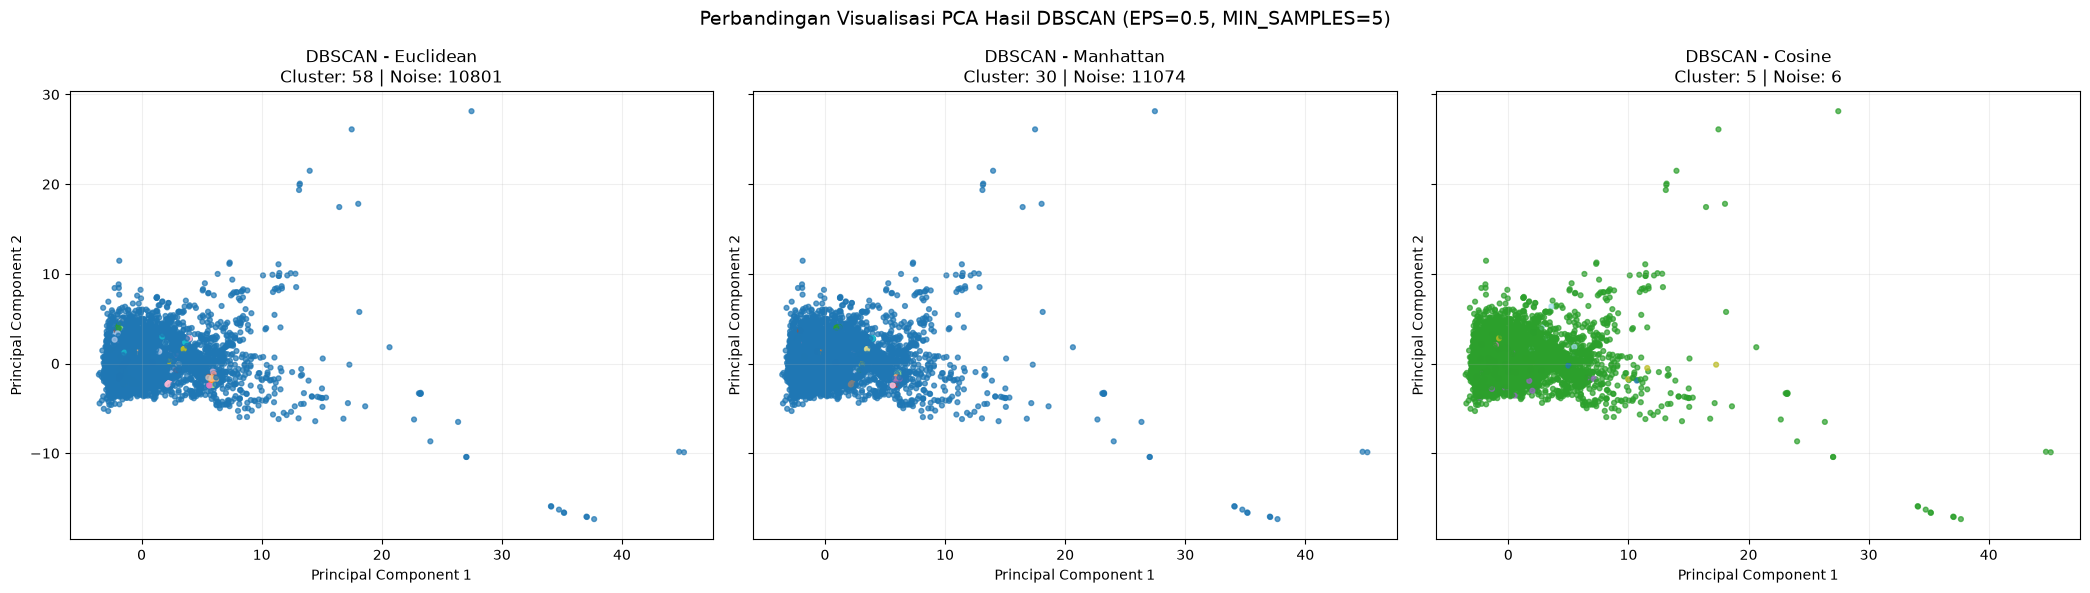

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)

for ax, metric in zip(axes, DISTANCE_METRICS):
    cluster_labels = cluster_labels_by_metric[metric]

    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_labels,
        cmap="tab20",
        s=12,
        alpha=0.7
    )

    n_clusters = len(set(cluster_labels)) - int(-1 in cluster_labels)
    n_noise = np.sum(cluster_labels == -1)

    ax.set_title(
        f"DBSCAN - {metric.title()}\n"
        f"Cluster: {n_clusters} | Noise: {n_noise}"
    )
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.grid(alpha=0.2)

plt.suptitle(
    f"Perbandingan Visualisasi PCA Hasil DBSCAN "
    f"(EPS={EPS}, MIN_SAMPLES={MIN_SAMPLES})",
    fontsize=14
)
plt.tight_layout()
plt.show()


### Visualisasi PCA per Distance Metric

Bagian berikut menampilkan plot yang lebih besar untuk masing-masing distance metric agar struktur kluster dan noise lebih mudah diamati.


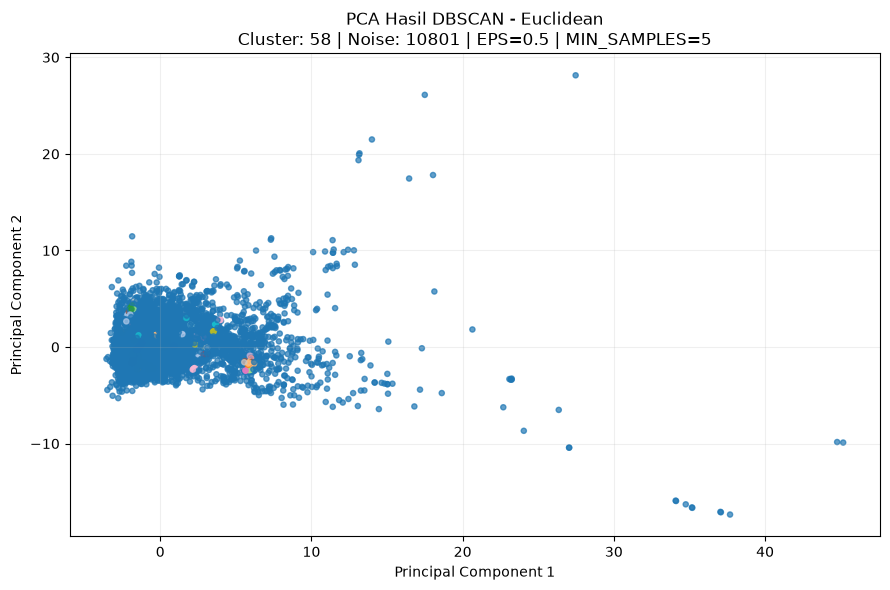

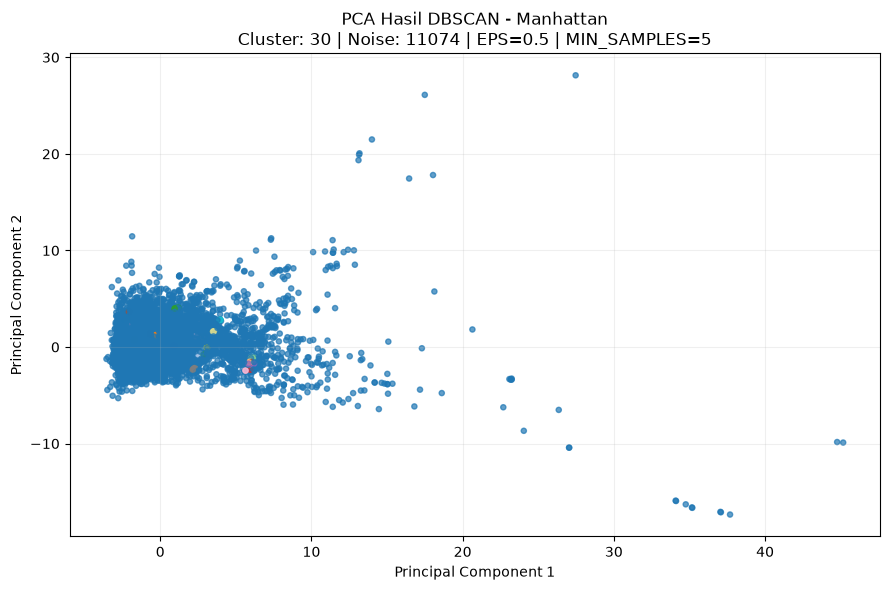

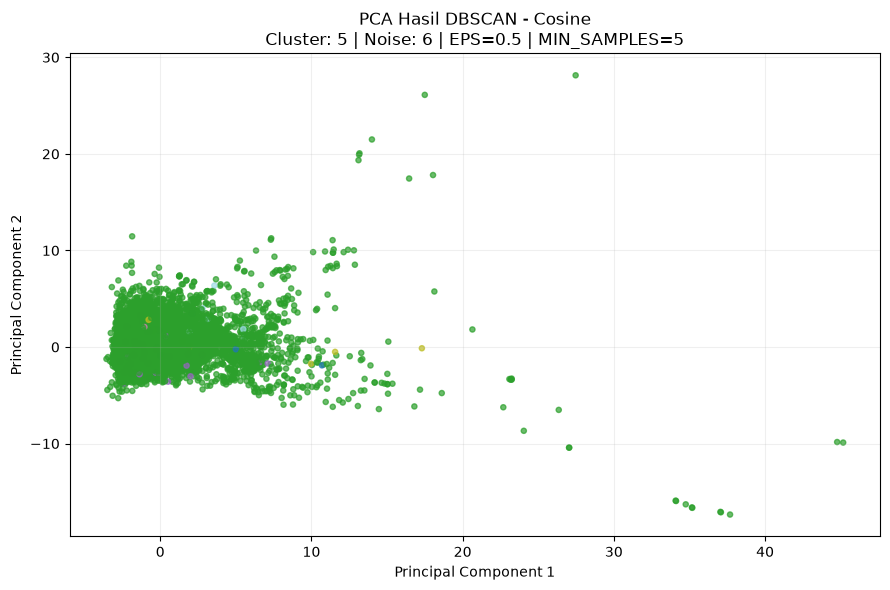

In [48]:
for metric in DISTANCE_METRICS:
    cluster_labels = cluster_labels_by_metric[metric]
    n_clusters = len(set(cluster_labels)) - int(-1 in cluster_labels)
    n_noise = np.sum(cluster_labels == -1)

    plt.figure(figsize=(9, 6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=cluster_labels,
        cmap="tab20",
        s=14,
        alpha=0.7
    )
    plt.title(
        f"PCA Hasil DBSCAN - {metric.title()}\n"
        f"Cluster: {n_clusters} | Noise: {n_noise} | "
        f"EPS={EPS} | MIN_SAMPLES={MIN_SAMPLES}"
    )
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


## 12. Diagram Batang Perbandingan

Diagram berikut mengikuti urutan dan gaya visual notebook referensi:

1. Jumlah Kluster
2. Silhouette Score
3. Waktu Eksekusi
4. Penggunaan Memori

Warna dibuat konsisten untuk setiap distance metric:

- **Euclidean** = biru
- **Manhattan** = oranye
- **Cosine** = hijau


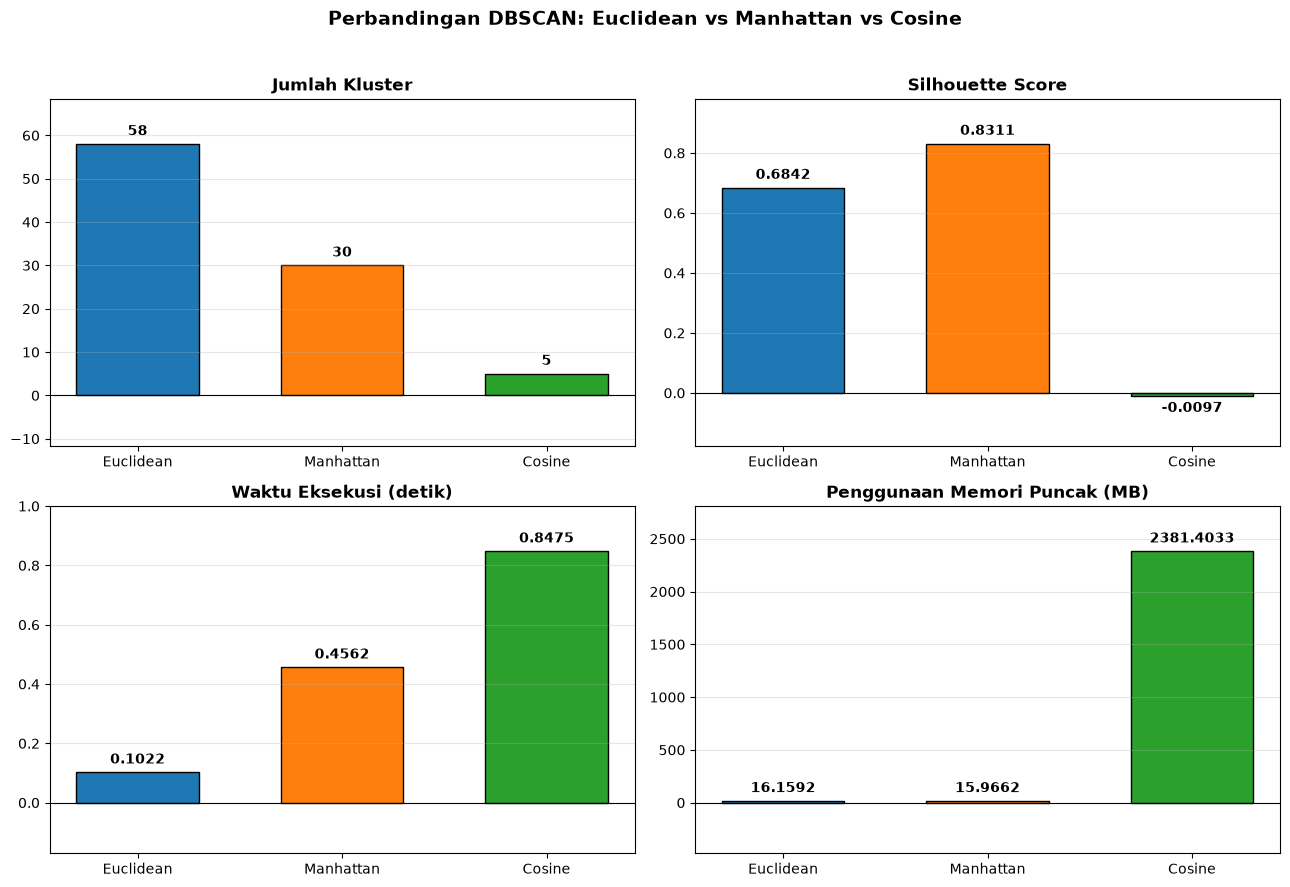

In [49]:
# Urutan dan warna mengikuti notebook referensi
nama = comparison_df["Distance Metric"].tolist()
warna = ["tab:blue", "tab:orange", "tab:green"]

panel = [
    ("Jumlah Kluster", "Jumlah Kluster", "{:.0f}"),
    ("Silhouette Score", "Silhouette Score", "{:.4f}"),
    ("Waktu Eksekusi (detik)", "Waktu Eksekusi (detik)", "{:.4f}"),
    ("Penggunaan Memori (MB)", "Penggunaan Memori Puncak (MB)", "{:.4f}"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (kolom, judul, fmt) in zip(axes.ravel(), panel):
    nilai = comparison_df[kolom].to_numpy(dtype=float)

    bars = ax.bar(
        nama,
        nilai,
        color=warna,
        edgecolor="black",
        width=0.6
    )

    ax.set_title(judul, fontweight="bold")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.grid(axis="y", alpha=0.3)

    nilai_valid = nilai[np.isfinite(nilai)]
    if len(nilai_valid) > 0:
        batas = max(np.max(np.abs(nilai_valid)), 1e-9)
        ymin = min(0, np.min(nilai_valid)) - 0.20 * batas
        ymax = np.max(nilai_valid) + 0.18 * batas
        if np.isclose(ymin, ymax):
            ymax = ymin + 1
        ax.set_ylim(ymin, ymax)

    for bar, value in zip(bars, nilai):
        if np.isfinite(value):
            ax.annotate(
                fmt.format(value),
                (bar.get_x() + bar.get_width() / 2, value),
                ha="center",
                va="bottom" if value >= 0 else "top",
                xytext=(0, 4 if value >= 0 else -4),
                textcoords="offset points",
                fontweight="bold"
            )
        else:
            ax.annotate(
                "N/A",
                (bar.get_x() + bar.get_width() / 2, 0),
                ha="center",
                va="bottom",
                xytext=(0, 4),
                textcoords="offset points",
                fontweight="bold"
            )

fig.suptitle(
    "Perbandingan DBSCAN: Euclidean vs Manhattan vs Cosine",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 13. Ringkasan

Gunakan tabel dan diagram untuk membandingkan ketiga distance metric dengan parameter yang identik.

Hal yang perlu diperhatikan:

- **Jumlah Kluster** tidak harus sama antar-distance metric karena definisi jaraknya berbeda.
- **Silhouette Score** pada setiap baris dihitung menggunakan metric yang sama dengan DBSCAN pada baris tersebut.
- **Waktu Eksekusi** hanya mengukur `fit_predict()`, bukan perhitungan Silhouette Score.
- **Penggunaan Memori** adalah peak tracked memory selama `fit_predict()` berdasarkan `tracemalloc`.
- `EPS = 0.5` dan `MIN_SAMPLES = 5` dipertahankan sama untuk Euclidean, Manhattan, dan Cosine sesuai tujuan perbandingan.
- PCA 2D hanya digunakan sebagai visualisasi perbandingan; proses DBSCAN tetap menggunakan seluruh fitur hasil StandardScaler.
